In [2]:

# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_exploded=df.explode('job_skills')

In [4]:
df_exploded=df_exploded[df_exploded['job_title_short']=='Data Scientist']

In [5]:
df_exploded['job_month']=df_exploded['job_posted_date'].dt.month

In [6]:
df_pivot=df_exploded.pivot_table(
    index='job_month',
    columns='job_skills',
    aggfunc='size',fill_value=0
)

In [7]:
df_pivot.loc['total_value']=df_pivot.sum()

In [8]:
df_pivot=df_pivot[df_pivot.loc['total_value'].sort_values(ascending=False).index]

In [9]:
df_pivot=df_pivot.drop('total_value',axis=0)

In [10]:
df_pivot

job_skills,python,sql,r,sas,tableau,aws,spark,azure,tensorflow,excel,...,huggingface,fastify,esquisse,workfront,play framework,nuxt.js,mattermost,shogun,sqlserver,wimi
job_month,,,,,,,,,,,,,,,,,,,,,
1,13998,9811,7566,3842,3446,3253,3222,2582,2316,2132,...,0,0,0,0,0,0,0,0,0,0
2,9551,6600,5064,2644,2566,2089,2085,1716,1525,1453,...,0,0,1,0,0,0,0,0,0,0
3,9210,6374,4971,2480,2456,2092,1992,1727,1405,1440,...,0,0,0,1,0,0,0,1,0,0
4,9135,6270,4873,2444,2447,2055,1905,1665,1546,1456,...,0,2,0,0,0,0,0,0,0,0
5,8029,5583,4228,2244,2271,1921,1716,1442,1271,1202,...,0,0,0,0,0,0,0,0,0,0
6,9338,6473,5019,2282,2432,2173,2072,1739,1580,1324,...,0,1,1,0,0,0,0,0,0,0
7,9400,6678,5029,2300,2547,2207,1972,1845,1535,1425,...,1,0,0,0,0,0,0,0,0,0
8,11193,8026,6089,3100,3013,2571,2466,2130,1972,1795,...,0,0,0,0,1,0,0,0,0,0
9,8393,5748,4153,2224,2062,1923,1820,1704,1462,1352,...,3,0,0,0,0,0,0,0,0,0


In [11]:
df['month']=df['job_posted_date'].dt.month

In [12]:
df=df[df['job_title_short']=='Data Scientist'].groupby('month').size()

In [13]:
df_pivot=df_pivot.div(df/100,axis=0)

In [14]:
df_pivot

job_skills,python,sql,r,sas,tableau,aws,spark,azure,tensorflow,excel,...,huggingface,fastify,esquisse,workfront,play framework,nuxt.js,mattermost,shogun,sqlserver,wimi
job_month,,,,,,,,,,,,,,,,,,,,,
1,67.427746,47.259152,36.445087,18.506744,16.599229,15.669557,15.520231,12.437380,11.156069,10.269750,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
2,68.461042,47.308437,36.298473,18.952046,18.392947,14.973837,14.945165,12.300194,10.931116,10.415024,...,0.000000,0.000000,0.007168,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
3,67.875304,46.974722,36.634977,18.276955,18.100081,15.417496,14.680522,12.727541,10.354484,10.612425,...,0.000000,0.000000,0.000000,0.007370,0.000000,0.000000,0.000000,0.00737,0.000000,0.000000
4,67.601569,46.399763,36.061570,18.086287,18.108488,15.207578,14.097536,12.321468,11.440835,10.774809,...,0.000000,0.014801,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
5,68.361005,47.535121,35.998297,19.106003,19.335888,16.355896,14.610473,12.277565,10.821626,10.234142,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
6,68.586118,47.543151,36.863753,16.760925,17.862651,15.960338,15.218509,12.772677,11.604848,9.724568,...,0.000000,0.007345,0.007345,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
7,66.304578,47.104465,35.472949,16.223461,17.965719,15.567468,13.909854,13.014037,10.827396,10.051492,...,0.007054,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
8,65.903203,47.256241,35.851390,18.252473,17.740226,15.137777,14.519548,12.541215,11.610928,10.568771,...,0.000000,0.000000,0.000000,0.000000,0.005888,0.000000,0.000000,0.00000,0.000000,0.000000
9,61.817780,42.336304,30.588495,16.380644,15.187449,14.163659,13.405023,12.550637,10.768211,9.958017,...,0.022096,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


In [15]:
df_pivot=df_pivot.reset_index()
df_pivot['month']=pd.to_datetime(df_pivot['job_month'],format='%m').dt.month_name()

In [16]:
df_pivot=df_pivot.set_index('month')

In [17]:
df_pivot=df_pivot.drop(columns='job_month')

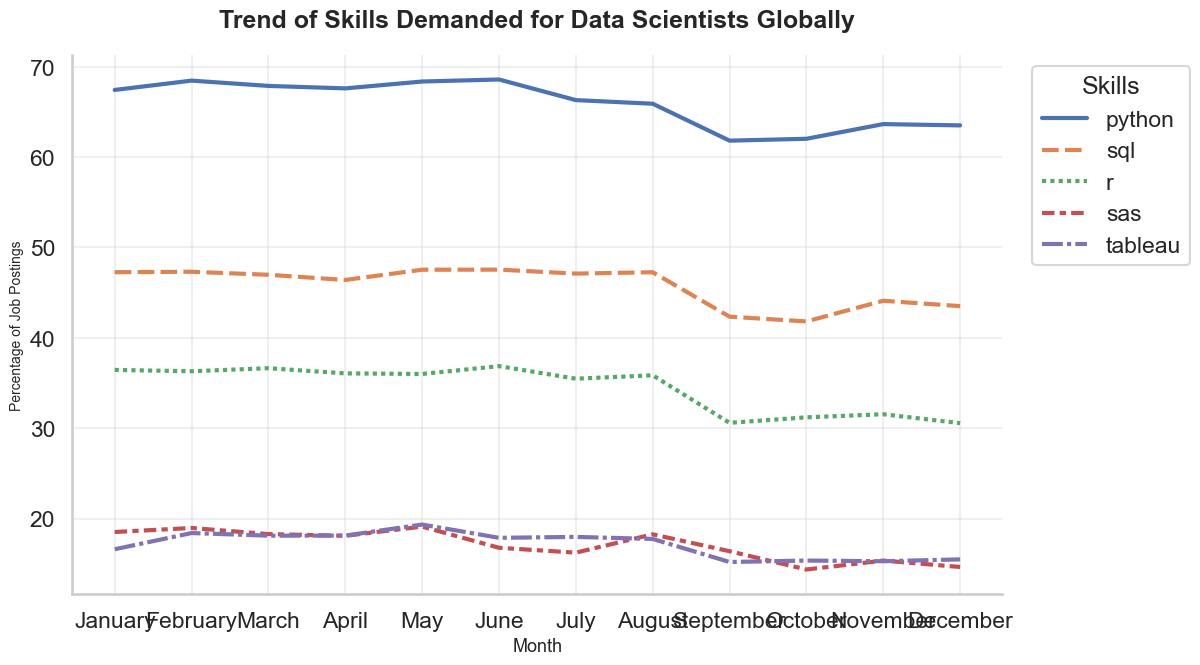

In [19]:

# Select top 5 skills
df_plot = df_pivot.iloc[:, :5]

# Theme
sns.set_theme(
    style="whitegrid",
    context="talk"
)

# Figure
plt.figure(figsize=(12, 7))

# Plot
sns.lineplot(
    data=df_plot,
    linewidth=3,
  
)

# Formatting
plt.title(
    "Trend of Skills Demanded for Data Scientists Globally",
    fontsize=18,
    pad=20,
    weight='bold'
)

plt.xlabel("Month", fontsize=13)
plt.ylabel("Percentage of Job Postings", fontsize=10)

plt.legend(
    title="Skills",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.grid(
    alpha=0.3,
  
)

sns.despine()


plt.show()